# Generate superpixel contours

In [1]:
import sys
import lightning as L
import torch
import kornia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from omegaconf import OmegaConf
from einops import rearrange
from tqdm.notebook import tqdm
from IPython.display import display, clear_output
from skimage.segmentation import felzenszwalb, slic, quickshift, watershed, mark_boundaries

sys.path.append("..")

from models.deep_superpixels_module import DeepSuperpixelsModule
from data.ibge_labeled import IBGE_Labeled_Module
from utils.train_utils import load_from_checkpoint, get_data_sample, time_series_to_rgb
from utils.metrics import AchievableSegmentationAccuracy, BoundaryPrecision, BoundaryRecall
from fusion.fusc import FuSC

/tatu/venv/ewab/lib/python3.12/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/tatu/venv/ewab/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2264: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/tatu/venv/ewab/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2264: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was 

In [2]:
mock_config = {
    "model": {
        "name": None,
        "patch_size": 256,
        "crop_size": 208,
        "num_channels": 4,
        "num_timestamps": 1
    },
    "dataset": {
        "name": "ibge_labeled",
        "batch_size": 16,
        "data_dir": "/pgeoprj2/godeep/ewab/datasets/IBGE_dataset_labeled",
        "fold": 1
    },
    "checkpoint": {
        "ckpt_path": None
    }
}

model_checkpoints = {
    "ssn": "/pgeoprj2/godeep/ewab/experiments/superpixels_benchmark/wandb/ckpt_ssn_fold_4/ssn_fold_4-epoch=187.ckpt",
    "spixel_net": "/pgeoprj2/godeep/ewab/experiments/superpixels_benchmark/wandb/ckpt_spixel_weight_fold_4/spixel_weight_fold_4-epoch=298.ckpt",
    "cdspixel_net": "/pgeoprj2/godeep/ewab/experiments/superpixels_benchmark/wandb/ckpt_cdspixel_fold_4/cdspixel_fold_4-epoch=299.ckpt"
}

config = OmegaConf.create(mock_config)

## Setting up data

In [3]:
SAMPLE_INDICES = [25, 45, 62, 107, 129, 131, 139, 155, 182, 183, 210, 223, 252, 257, 807]

data_module = IBGE_Labeled_Module(config)
data_module.setup()

print("Total number of test samples:", len(data_module.test_dataset))
subset_loader = get_data_sample(data_module.test_dataset, indices=SAMPLE_INDICES)

Total number of test samples: 1046


## Shallow superpixel algorithms

In [4]:
algorithms = {
    slic: {"n_segments": 169, "compactness": 0.1, "convert2lab": False},
    felzenszwalb: {"scale": 25, "sigma": 1.0, "min_size": 169, "channel_axis": -1},
    quickshift: {"ratio": 0.75, "kernel_size": 3, "convert2lab": False},
    watershed: {"markers": 169, "compactness": 0.001}
}

In [5]:
alg_preds = {}

for alg, args in algorithms.items():
    print(f"Generating contours with {alg.__name__}")
    preds = []
    
    for i in tqdm(SAMPLE_INDICES):
        x = data_module.test_dataset[i]["data"]

        if alg.__name__ == "watershed":
            x = rearrange(x, "c t h w -> 1 (c t) h w").cpu()

            # Watershed expects a 2D gradient map
            x = kornia.filters.sobel(x)
            x, _ = torch.max(x, dim=1)
            x = x.squeeze().numpy()
        else:
            x = rearrange(x, "c t h w -> h w (c t)").cpu()
        
        pred = torch.tensor(alg(x, **args))
        preds.append(pred.unsqueeze(0))

    alg_preds[alg.__name__] = torch.stack(preds, dim=0)

Generating contours with slic


  0%|          | 0/15 [00:00<?, ?it/s]

Generating contours with felzenszwalb


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_3324436/1762252181.py:20: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  pred = torch.tensor(alg(x, **args))


Generating contours with quickshift


  0%|          | 0/15 [00:00<?, ?it/s]

Generating contours with watershed


  0%|          | 0/15 [00:00<?, ?it/s]

## Deep superpixel model

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deep_preds = {}

model_module = DeepSuperpixelsModule
trainer = L.Trainer(barebones=True)

for model_name, ckpt_path in model_checkpoints.items():
    config.model.name = model_name
    config.checkpoint.ckpt_path = ckpt_path
    
    model = model_module(config)
    model = load_from_checkpoint(config, model, model_name=model_module)
    model = model.to(device)
    
    outputs = trainer.predict(model, dataloaders=subset_loader)
    deep_preds[model_name] = outputs

You are running in `Trainer(barebones=True)` mode. All features that may impact raw speed have been disabled to facilitate analyzing the Trainer overhead. Specifically, the following features are deactivated:
 - Checkpointing: `Trainer(enable_checkpointing=True)`
 - Progress bar: `Trainer(enable_progress_bar=True)`
 - Model summary: `Trainer(enable_model_summary=True)`
 - Logging: `Trainer(logger=True)`, `Trainer(log_every_n_steps>0)`, `LightningModule.log(...)`, `LightningModule.log_dict(...)`
 - Sanity checking: `Trainer(num_sanity_val_steps>0)`
 - Development run: `Trainer(fast_dev_run=True)`
 - Anomaly detection: `Trainer(detect_anomaly=True)`
 - Profiling: `Trainer(profiler=...)`
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platfo

Using device: cuda


`Trainer(barebones=True)` started running. The progress bar is disabled so you might want to manually print the progress in your model.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/tatu/venv/ewab/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer(barebones=True)` started running. The progress bar is disabled so you might want to manually print the progress in your model.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
`Trainer(barebones=True)` started running. The progress bar is disabled so you might want to manually print the progress in your model.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal 

## Computing metrics

## Results visualization

In [7]:
def update(image_idx, timestamp):
    with out_img:
        out_img.clear_output(wait=True)

        num_rows = np.ceil((2 + len(algorithms) + len(model_checkpoints)) / 3).astype(np.uint8)
        fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(12, 12))
        axes = axes.flatten()
        
        # Plot image
        image = time_series_to_rgb(data_module.test_dataset[SAMPLE_INDICES[image_idx]]["data"])
        axes[0].imshow(image[timestamp])
        axes[0].set_title(f"Image")
        
        # Plot segmentation mask
        target = data_module.test_dataset[SAMPLE_INDICES[image_idx]]["target"].squeeze()
        axes[1].imshow(target, cmap="gray")
        axes[1].set_title(f"Segmentation mask")
        
        # Shallow superpixel predictions
        for i, (alg_name, pred) in enumerate(alg_preds.items(), start=2):
            # Plot superpixel contours
            pred = mark_boundaries(image[timestamp], pred[image_idx].squeeze().numpy())
            
            axes[i].imshow(image[timestamp])
            axes[i].imshow(pred)
            axes[i].set_title(alg_name.upper())
        
        # Deep superpixel predictions
        
        # CHANGE LATER!!!
        paper_model_names = {
            "ssn": "SSN",
            "spixel_net": "S-FCN",
            "cdspixel_net": "CDS"
        }
        
        for i, (model_name, outputs) in enumerate(deep_preds.items()):
            deep_pred = outputs[0]["preds"]
            deep_pred = mark_boundaries(image[timestamp], deep_pred[image_idx].squeeze().numpy())
            
            axes[2 + len(alg_preds) + i].imshow(image[timestamp])
            axes[2 + len(alg_preds) + i].imshow(deep_pred)
            axes[2 + len(alg_preds) + i].set_title(paper_model_names[model_name].upper())
    
        for a in axes.ravel():
            a.set_axis_off()
        
        plt.tight_layout()
        plt.show()

def on_slider_change(change):
    update(img_slider.value, frame_slider.value)

In [8]:
img_slider = widgets.IntSlider(value=0, min=0, max=len(SAMPLE_INDICES)-1, step=1, description="Image index")
frame_slider = widgets.IntSlider(value=0, min=0, max=config.model.num_timestamps-1, step=1, description="Timestamp")

out_table = widgets.Output()
out_img = widgets.Output()

img_slider.observe(on_slider_change, names="value")
frame_slider.observe(on_slider_change, names="value")

ui = widgets.VBox([
    img_slider,
    frame_slider,
    out_table,
    out_img
])
display(ui)

## Superpixel fusion

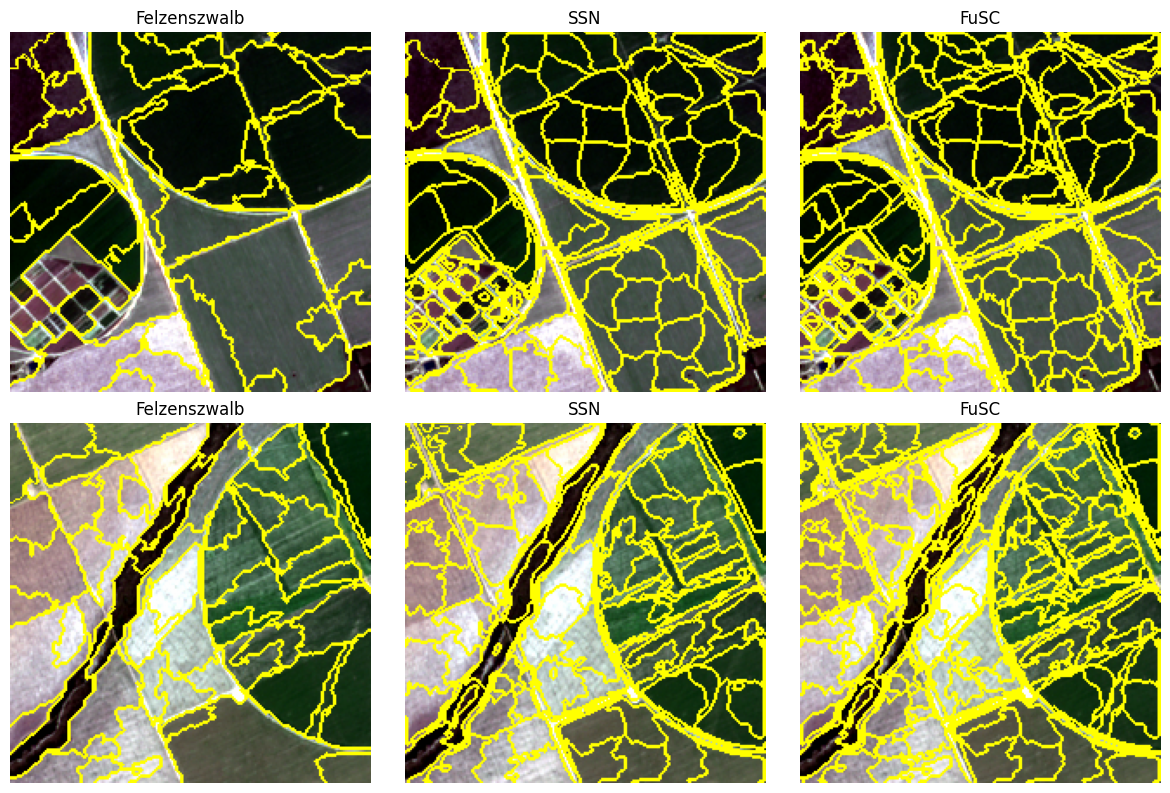

In [33]:
indices = [9, 5]

fig, axes = plt.subplots(nrows=len(indices), ncols=3, figsize=(12, 8))

for i, image_idx in enumerate(indices):
    image = time_series_to_rgb(data_module.test_dataset[SAMPLE_INDICES[image_idx]]["data"])[0]
    
    contours_1 = alg_preds["felzenszwalb"][image_idx].squeeze().numpy()
    contours_2 = deep_preds["ssn"][0]["preds"][image_idx].squeeze().numpy()

    merged_contours = FuSC(contours_1, contours_2, image, 20)

    axes[i, 0].imshow(mark_boundaries(image, contours_1))
    axes[i, 0].set_title("Felzenszwalb")
    
    axes[i, 1].imshow(mark_boundaries(image, contours_2))
    axes[i, 1].set_title("SSN")
    
    axes[i, 2].imshow(mark_boundaries(image, merged_contours))
    axes[i, 2].set_title("FuSC")

for a in axes.ravel():
    a.set_axis_off()

plt.tight_layout()
plt.show()